In [ ]:
from google.colab import files
uploaded = files.upload()

Saving UCI_Credit_Card.csv to UCI_Credit_Card.csv


Dataset loaded successfully!

Dataset Shape:
(30000, 25)

First 5 Rows:
   ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  PAY_4  \
0   1    20000.0    2          2         1   24      2      2     -1     -1   
1   2   120000.0    2          2         2   26     -1      2      0      0   
2   3    90000.0    2          2         2   34      0      0      0      0   
3   4    50000.0    2          2         1   37      0      0      0      0   
4   5    50000.0    1          2         1   57     -1      0     -1      0   

   ...  BILL_AMT4  BILL_AMT5  BILL_AMT6  PAY_AMT1  PAY_AMT2  PAY_AMT3  \
0  ...        0.0        0.0        0.0       0.0     689.0       0.0   
1  ...     3272.0     3455.0     3261.0       0.0    1000.0    1000.0   
2  ...    14331.0    14948.0    15549.0    1518.0    1500.0    1000.0   
3  ...    28314.0    28959.0    29547.0    2000.0    2019.0    1200.0   
4  ...    20940.0    19146.0    19131.0    2000.0   36681.0   10000.0   

   PAY_AMT4  P

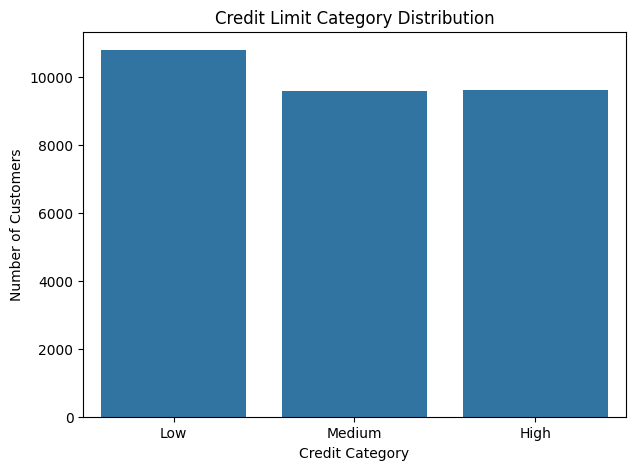


Feature Engineering Completed!

Feature Shape:
(30000, 29)

Target Shape:
(30000,)

Training Data Shape:
(24000, 29)

Testing Data Shape:
(6000, 29)

Feature Scaling Completed!


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Multinomial Logistic Regression Model Trained!

First 10 Predictions:
[2 2 0 2 1 0 0 0 0 0]

Prediction Probabilities:
[[0.00550783 0.14416688 0.85032529]
 [0.14229731 0.42878087 0.42892182]
 [0.81944977 0.15026705 0.03028318]
 [0.00718009 0.28897302 0.70384689]
 [0.23755276 0.39989162 0.36255562]
 [0.47294115 0.30833542 0.21872343]
 [0.73051627 0.18348352 0.08600021]
 [0.65868785 0.25521669 0.08609546]
 [0.78247099 0.17691305 0.04061596]
 [0.83483302 0.12805638 0.0371106 ]]

MULTINOMIAL LOGISTIC REGRESSION RESULTS
Accuracy : 0.6108333333333333
Precision: 0.5970667026302029
Recall   : 0.6108333333333333
F1 Score : 0.5967388446006666

Classification Report:
               precision    recall  f1-score   support

   Low Credit       0.65      0.81      0.72      2160
Medium Credit       0.51      0.36      0.42      1916
  High Credit       0.62      0.64      0.63      1924

     accuracy                           0.61      6000
    macro avg       0.59      0.60      0.59      6000
 w

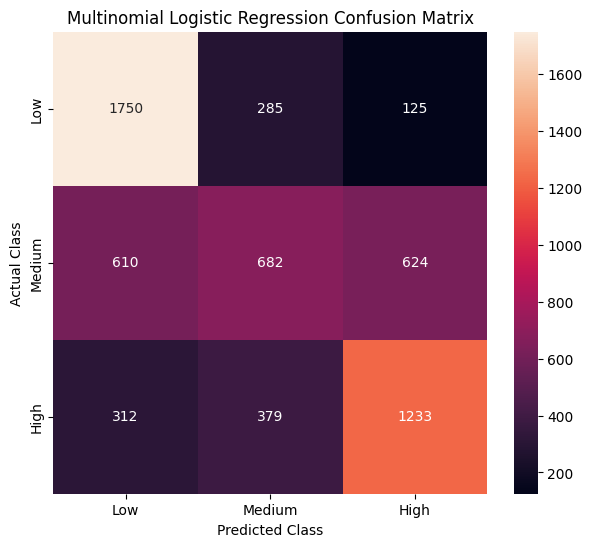


MODEL COEFFICIENTS
                   SEX  EDUCATION  MARRIAGE       AGE     PAY_0     PAY_2  \
Low Credit    -0.10154   0.349371  0.125098 -0.151290  0.314968  0.308308   
Medium Credit  0.06281  -0.006753 -0.010255 -0.022127 -0.097121 -0.056641   
High Credit    0.03873  -0.342617 -0.114843  0.173417 -0.217847 -0.251668   

                  PAY_3     PAY_4     PAY_5     PAY_6  ...  PAY_AMT4  \
Low Credit     0.179117  0.153496  0.141563  0.243225  ... -0.017107   
Medium Credit -0.032825 -0.073472 -0.062595 -0.023801  ... -0.020257   
High Credit   -0.146292 -0.080024 -0.078968 -0.219425  ...  0.037365   

               PAY_AMT5  PAY_AMT6  TOTAL_BILL_AMT  AVG_BILL_AMT  \
Low Credit    -0.146785 -0.324632       -0.192003     -0.192003   
Medium Credit  0.016720  0.112586        0.066700      0.066700   
High Credit    0.130065  0.212045        0.125303      0.125303   

               TOTAL_PAYMENT_AMT  AVG_PAYMENT_AMT  AVG_REPAYMENT_STATUS  \
Low Credit             -0.217622      

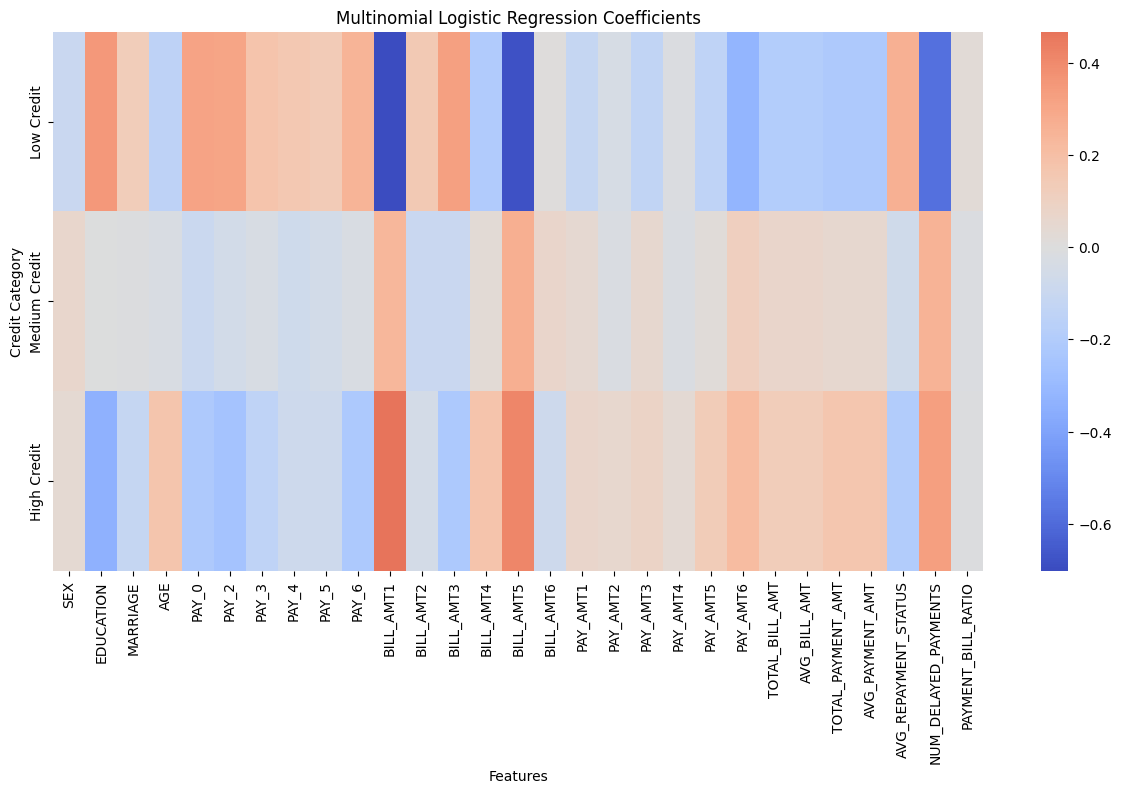


SINGLE CUSTOMER PREDICTION
Predicted Category: HIGH CREDIT

Class Probabilities:
Low Credit   : 0.005507826736802978
Medium Credit: 0.1441668790273862
High Credit  : 0.8503252942358107

MULTINOMIAL LOGISTIC REGRESSION COMPLETED!
Accuracy : 0.6108
Precision: 0.5971
Recall   : 0.6108
F1 Score : 0.5967


In [ ]:

# MULTINOMIAL LOGISTIC REGRESSION PROJECT
# UCI CREDIT CARD DATASET

# -------------------- 1. IMPORT LIBRARIES --------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


# ============================================================
# 2. LOAD DATASET
# ============================================================

df = pd.read_csv("UCI_Credit_Card.csv")

print("Dataset loaded successfully!")

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())


# ============================================================
# 3. BASIC DATA INFORMATION
# ============================================================

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


# ============================================================
# 4. REMOVE DUPLICATES
# ============================================================

df = df.drop_duplicates()

print("\nShape after removing duplicates:")
print(df.shape)


# ============================================================
# 5. CREATE MULTICLASS TARGET
# ============================================================

# We use LIMIT_BAL to create 3 credit-limit categories.
#
# 0 = Low Credit Limit
# 1 = Medium Credit Limit
# 2 = High Credit Limit

df["CREDIT_CATEGORY"] = pd.qcut(
    df["LIMIT_BAL"],
    q=3,
    labels=[0, 1, 2]
)

# Convert target to integer
df["CREDIT_CATEGORY"] = (
    df["CREDIT_CATEGORY"].astype(int)
)


print("\nMulticlass Target Distribution:")
print(
    df["CREDIT_CATEGORY"].value_counts().sort_index()
)


# ============================================================
# 6. TARGET VISUALIZATION
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    x="CREDIT_CATEGORY",
    data=df
)

plt.title("Credit Limit Category Distribution")
plt.xlabel("Credit Category")
plt.ylabel("Number of Customers")

plt.xticks(
    [0, 1, 2],
    ["Low", "Medium", "High"]
)

plt.show()


# ============================================================
# 7. FEATURE ENGINEERING
# ============================================================

# -------------------- BILL FEATURES --------------------------

bill_columns = [
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6"
]

df["TOTAL_BILL_AMT"] = (
    df[bill_columns].sum(axis=1)
)

df["AVG_BILL_AMT"] = (
    df[bill_columns].mean(axis=1)
)


# -------------------- PAYMENT FEATURES -----------------------

payment_columns = [
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

df["TOTAL_PAYMENT_AMT"] = (
    df[payment_columns].sum(axis=1)
)

df["AVG_PAYMENT_AMT"] = (
    df[payment_columns].mean(axis=1)
)


# -------------------- REPAYMENT FEATURES ---------------------

pay_status_columns = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

df["AVG_REPAYMENT_STATUS"] = (
    df[pay_status_columns].mean(axis=1)
)

df["NUM_DELAYED_PAYMENTS"] = (
    df[pay_status_columns] > 0
).sum(axis=1)


# -------------------- PAYMENT-BILL RATIO ---------------------

df["PAYMENT_BILL_RATIO"] = (
    df["TOTAL_PAYMENT_AMT"] /
    (df["TOTAL_BILL_AMT"] + 1)
)


print("\nFeature Engineering Completed!")


# ============================================================
# 8. SELECT FEATURES
# ============================================================

features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "AGE",

    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6",

    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",

    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6",

    # Engineered features
    "TOTAL_BILL_AMT",
    "AVG_BILL_AMT",
    "TOTAL_PAYMENT_AMT",
    "AVG_PAYMENT_AMT",
    "AVG_REPAYMENT_STATUS",
    "NUM_DELAYED_PAYMENTS",
    "PAYMENT_BILL_RATIO"
]


X = df[features]

y = df["CREDIT_CATEGORY"]


print("\nFeature Shape:")
print(X.shape)

print("\nTarget Shape:")
print(y.shape)


# ============================================================
# 9. HANDLE MISSING / INFINITE VALUES
# ============================================================

X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.fillna(0)


# ============================================================
# 10. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("\nTraining Data Shape:")
print(X_train.shape)

print("\nTesting Data Shape:")
print(X_test.shape)


# ============================================================
# 11. FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("\nFeature Scaling Completed!")


# ============================================================
# 12. CREATE MULTINOMIAL LOGISTIC REGRESSION
# ============================================================

model = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=1000,
    random_state=42
)


# ============================================================
# 13. TRAIN MODEL
# ============================================================

model.fit(
    X_train_scaled,
    y_train
)

print("\nMultinomial Logistic Regression Model Trained!")


# ============================================================
# 14. MAKE PREDICTIONS
# ============================================================

y_pred = model.predict(
    X_test_scaled
)

y_probability = model.predict_proba(
    X_test_scaled
)


print("\nFirst 10 Predictions:")
print(y_pred[:10])

print("\nPrediction Probabilities:")
print(y_probability[:10])


# ============================================================
# 15. MODEL EVALUATION
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)


print("\n================================================")
print("MULTINOMIAL LOGISTIC REGRESSION RESULTS")
print("================================================")

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)


# ============================================================
# 16. CLASSIFICATION REPORT
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Low Credit",
            "Medium Credit",
            "High Credit"
        ]
    )
)


# ============================================================
# 17. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(7, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Low",
        "Medium",
        "High"
    ],
    yticklabels=[
        "Low",
        "Medium",
        "High"
    ]
)

plt.title("Multinomial Logistic Regression Confusion Matrix")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.show()


# ============================================================
# 18. FEATURE COEFFICIENTS
# ============================================================

# Multinomial Logistic Regression creates
# separate coefficients for each class.

coefficient_table = pd.DataFrame(
    model.coef_,
    columns=features,
    index=[
        "Low Credit",
        "Medium Credit",
        "High Credit"
    ]
)

print("\n================================================")
print("MODEL COEFFICIENTS")
print("================================================")

print(coefficient_table)


# ============================================================
# 19. COEFFICIENT VISUALIZATION
# ============================================================

plt.figure(figsize=(15, 7))

sns.heatmap(
    coefficient_table,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Multinomial Logistic Regression Coefficients"
)

plt.xlabel("Features")
plt.ylabel("Credit Category")

plt.xticks(rotation=90)

plt.show()


# ============================================================
# 20. PREDICT A SINGLE CUSTOMER
# ============================================================

# Take one customer from test data

sample_customer = X_test.iloc[[0]]

sample_customer_scaled = scaler.transform(
    sample_customer
)

sample_prediction = model.predict(
    sample_customer_scaled
)

sample_probability = model.predict_proba(
    sample_customer_scaled
)[0]


print("\n================================================")
print("SINGLE CUSTOMER PREDICTION")
print("================================================")

if sample_prediction[0] == 0:

    print("Predicted Category: LOW CREDIT")

elif sample_prediction[0] == 1:

    print("Predicted Category: MEDIUM CREDIT")

else:

    print("Predicted Category: HIGH CREDIT")


print("\nClass Probabilities:")

print("Low Credit   :", sample_probability[0])
print("Medium Credit:", sample_probability[1])
print("High Credit  :", sample_probability[2])


# ============================================================
# 21. FINAL SUMMARY
# ============================================================

print("\n================================================")
print("MULTINOMIAL LOGISTIC REGRESSION COMPLETED!")
print("================================================")

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))